In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
from xgcm import Grid

In [2]:
wind = xr.open_dataset("Files/wind_stress_zonal_monthly_maps.nc")
wind_z = xr.open_dataset("Files/wind_stress_zonal_coefficients.nc")
wind_curl = xr.open_dataset("Files/wind_stress_curl_monthly_maps.nc")
wind_curl_z = xr.open_dataset("Files/wind_stress_curl_coefficients.nc")

In [3]:
wind = wind.where(wind >= -100)

In [4]:
jan = wind.january
feb = wind.february
mar = wind.march
apr = wind.april
may = wind.may
jun = wind.june
jul = wind.july
aug = wind.august
sep = wind.september
octo = wind.october
nov = wind.november
dec = wind.december

In [5]:
months = list(wind.data_vars)

wind_stacked = xr.concat(
    [wind[m] for m in months],
    dim='month'
).assign_coords(month=months)


In [6]:
month_mean=wind_stacked.mean('month')
meriprof = month_mean.mean('longitude')

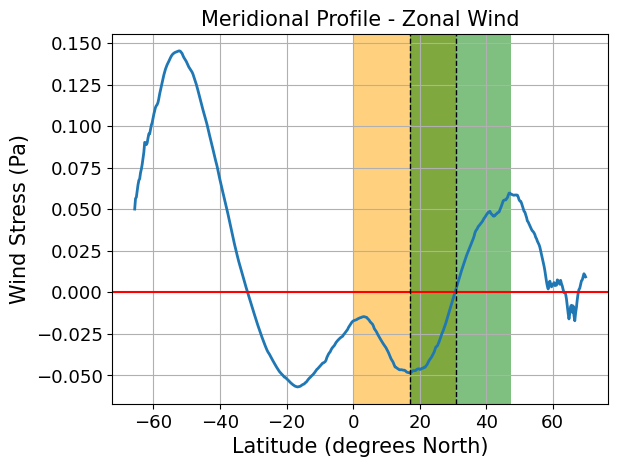

In [42]:
meriprof.plot(linewidth=2)
plt.title('Meridional Profile - Zonal Wind', fontsize=15)
plt.gca().set_xlabel('Latitude (degrees North)', fontsize=15)
plt.gca().set_ylabel('Wind Stress (Pa)', fontsize=15)
plt.tick_params(axis='both', labelsize=13)
plt.grid()
plt.axhline(y=0, c='r')
a=0
b=31
c=17
d=47.5
plt.axvspan(a, b, color='orange', alpha=0.5, lw=0)
plt.axvspan(c, d, color='green', alpha=0.5, lw=0)
plt.axvline(x=17, linestyle='--', c='black', linewidth=1)
plt.axvline(x=31, linestyle='--', c='black', linewidth=1)

plt.savefig('Images/realisticwindprofile.png')